<a href="https://colab.research.google.com/github/BridgingAISocietySummerSchools/Python-for-Data-Science-Workshop/blob/main/02_advanced_self_learning/08_data_cleaning_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧹 Notebook 8 — Data Cleaning and Preprocessing

> **Advanced & Self-Learning Track — Notebook 8 of 14** · **Estimated time:** 45–55 min · **Difficulty:** Intermediate-beginner
>
> This track is the self-paced deep-dive of the course. The 90-minute live **Introduction Session** lives in `01_introduction/`.

**This notebook builds directly on [Notebook 7 — Pandas Essentials](07_pandas_essentials.ipynb).** There you learned how to
*handle* a table: create a `DataFrame`, select with `[]` / `.loc` / `.iloc`, filter with boolean masks, and aggregate with
`groupby`. Every one of those tools is assumed knowledge here. What is new is the *reality* of data: the tables you meet
outside a textbook are misspelled, half-empty, duplicated, and typed wrong — and no amount of clever modelling repairs that.

## 🎯 Learning objectives

By the end of this notebook you will be able to:

1. Run a repeatable **data audit** on any new table (`.info()`, `.describe()`, `.isna().sum()`, `.duplicated().sum()`, `.nunique()`).
2. Detect **missing values**, tell *missing at random* from *missing for a reason*, and choose between dropping, filling and forward-filling — knowing what each choice costs.
3. Repair **wrong dtypes** with `pd.to_numeric(..., errors="coerce")` and `pd.to_datetime(..., format=...)`, and explain how a wrong dtype silently poisons later analysis.
4. Remove **duplicates** safely, including subset-based deduplication — and say when *not* to.
5. Standardise **inconsistent categories** with `.str.strip()`, `.str.title()` and mapping/`.replace()`.
6. Flag **outliers** with an IQR rule and a z-score, and distinguish an *error* from a *real extreme value*.
7. Apply basic **preprocessing for modelling**: scaling (manual z-score and `StandardScaler`) and one-hot encoding with `pd.get_dummies`.
8. Wrap the whole pipeline into a documented, reusable `clean_dataset()` function.

## ✅ Prerequisites

- Track 1's 90-minute session, or Track 2 Notebooks 1–6 (variables, control flow, lists/dicts, functions, NumPy).
- **Notebook 7 — Pandas Essentials**: `DataFrame` basics, `.loc` / `.iloc`, boolean filtering, `groupby`.

Nothing is downloaded: we generate a deliberately messy table in-notebook so that every defect is known and
every fix is checkable.

## 1. Why cleaning dominates the job

Every survey of working data scientists says roughly the same thing: **the majority of the time goes into finding,
cleaning and reshaping data**, not into fitting models. Course material usually hides this, because a tidy CSV makes
for a tidier lesson. That is the single biggest gap between a tutorial and a real project.

Why does messiness happen? Because data is produced by *people and devices*, not by statisticians:

| Where it comes from | What you get |
|---|---|
| Free-text web forms | `"Berlin"`, `"berlin"`, `" Berlin "`, `"Bwrlin"` |
| Optional questions | missing income, missing age — and *not at random* |
| Spreadsheets | numbers stored as text, `"n/a"`, German decimal commas (`"2,5"`) |
| Re-submitted forms / merged exports | duplicated rows, duplicated IDs with different answers |
| Sensors & manual entry | `217` years old, a temperature of `-999` |

The consequence is uncomfortable but important:

> ### 🥇 The golden rule
> **Look at your data before you model it.**
> A model cannot tell you that a column is broken. It will happily fit the broken version and give you a
> confident number. `df.info()` costs one second; a wrong conclusion can cost a project.

Cleaning is also not a mechanical chore — it is a sequence of *decisions*. We will keep asking the same two
questions after each step: **what did I change, and who does that change affect?**

## 2. Setup and a deliberately messy dataset

We build a small **community survey** table: 48 rows, the kind of thing you would get out of a web form.
The clean part is drawn with `numpy.random.default_rng(seed)` (reproducible for everyone), then we
*hand-place* the defects — misspellings, missing values, string numbers, duplicates, one typo and one genuine
extreme value. Because we planted them, we can verify every repair.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Bridging AI & Society course plot style -------------------------------
BAS_BLUE = "#416bcc"   # brand accent (lapis blue) — primary series
BAS_INK  = "#1c2025"   # brand ink — text/edges where needed
# supporting colours, chosen to sit well next to the lapis accent:
BAS_AMBER  = "#d9822b"   # secondary series / contrast
BAS_GREEN  = "#3a9e6e"   # "good" / positive
BAS_RED    = "#c8504f"   # "bad" / warnings / errors
BAS_PURPLE = "#7a5fb5"   # tertiary series
BAS_GREY   = "#8a919c"   # de-emphasised / reference lines
BAS_PALETTE = [BAS_BLUE, BAS_AMBER, BAS_GREEN, BAS_RED, BAS_PURPLE, BAS_GREY]

plt.rcParams["axes.prop_cycle"] = plt.cycler(color=BAS_PALETTE)

# Show a few more rows/columns without truncation
pd.set_option("display.width", 110)
pd.set_option("display.max_columns", 20)

print(f"pandas {pd.__version__} · numpy {np.__version__}")

pandas 2.3.3 · numpy 2.0.2


The generator below is worth reading once — it is a catalogue of the defects you will meet in the wild.
Note that it returns **strings** for two columns on purpose (`hours_online`, `signup_date`), exactly as a CSV
export would.

In [2]:
def make_messy_survey(seed: int = 42) -> pd.DataFrame:
    """Return a small, deliberately messy community-survey table.

    Clean values are drawn reproducibly with `default_rng(seed)`; the defects are
    placed by hand so that every one of them can be found and verified later.
    """
    rng = np.random.default_rng(seed)
    n = 46

    city = rng.choice(["Berlin", "Munich", "Hamburg"], size=n, p=[0.45, 0.30, 0.25])
    age = rng.integers(19, 69, size=n).astype(float)
    income = np.round(rng.normal(2900, 700, size=n) + (age - 40) * 20, -1)
    hours = np.round(rng.gamma(2.2, 1.3, size=n) + 0.3, 1)
    satisfaction = rng.integers(1, 6, size=n).astype(float)
    signup = pd.Timestamp("2024-01-05") + pd.to_timedelta(rng.integers(0, 300, size=n), unit="D")

    df = pd.DataFrame({
        "respondent_id": np.arange(1001, 1001 + n),
        "signup_date": signup.strftime("%Y-%m-%d"),        # dates as TEXT, like a CSV
        "city": city.astype(object),
        "age": age,
        "income_eur": income,
        "hours_online": [f"{h:.1f}" for h in hours],       # numbers as TEXT, like a CSV
        "satisfaction": satisfaction,
    })

    # --- defect 1: inconsistent category spellings (free-text form) -----------
    messy_city = {2: "berlin", 5: " Berlin ", 9: "BERLIN",
                  14: "munich", 21: "Muenchen", 28: "hamburg",
                  33: "Hamburg ", 40: "MUNICH"}
    for pos, value in messy_city.items():
        df.loc[pos, "city"] = value

    # --- defect 2: missing + impossible ages ---------------------------------
    df.loc[[6, 30], "age"] = np.nan
    df.loc[18, "age"] = 217.0            # a typo, not a person

    # --- defect 3: a missing date and two missing ratings --------------------
    df.loc[8, "signup_date"] = ""
    df.loc[[4, 17], "satisfaction"] = np.nan

    # --- defect 4: missing income, and NOT at random -------------------------
    # these six rows are the younger / less satisfied respondents: they are the
    # ones who skipped the income question. The missingness carries information.
    df.loc[[3, 19, 24, 26, 29, 34], "income_eur"] = np.nan
    df.loc[12, "income_eur"] = 21500.0   # a REAL high earner, not an error

    # --- defect 5: unparseable / locale-formatted numbers --------------------
    df.loc[3, "hours_online"] = "n/a"
    df.loc[11, "hours_online"] = ""
    df.loc[25, "hours_online"] = "2,5"   # German decimal comma
    df.loc[38, "hours_online"] = "1,8"

    # --- defect 6: duplicates -----------------------------------------------
    exact_copy = df.loc[[15]]                      # the same row submitted twice
    resubmission = df.loc[[20]].copy()             # same person, corrected answer
    resubmission["satisfaction"] = 2.0
    resubmission["hours_online"] = "4.0"

    df = pd.concat([df, exact_copy, resubmission], ignore_index=True)
    return df


raw = make_messy_survey()
raw.head(8)

,respondent_id,signup_date,city,age,income_eur,hours_online,satisfaction
0,1001,2024-02-23,Hamburg,61.0,3000.0,1.0,5.0
1,1002,2024-07-01,Berlin,38.0,3460.0,1.9,4.0
2,1003,2024-02-28,berlin,63.0,3230.0,2.8,4.0
3,1004,2024-10-10,Munich,33.0,NaN,n/a,3.0
4,1005,2024-08-13,Berlin,30.0,1910.0,3.1,NaN
5,1006,2024-09-02,Berlin,53.0,2520.0,6.0,1.0
6,1007,2024-05-13,Hamburg,NaN,3450.0,3.4,5.0
7,1008,2024-05-24,Hamburg,25.0,2700.0,1.2,5.0


## 3. First inspection — the data audit

Resist the urge to compute anything yet. The first five minutes with a new table are always the same five
commands. Run them in this order, and *read* the output instead of scrolling past it.

In [3]:
print("shape (rows, columns):", raw.shape)
print()
print("dtypes:")
print(raw.dtypes)

shape (rows, columns): (48, 7)

dtypes:
respondent_id      int64
signup_date       object
city              object
age              float64
income_eur       float64
hours_online      object
satisfaction     float64
dtype: object


**Read it.** `shape` says 48 rows — but the generator drew 46, so two rows arrived from somewhere (duplicates).
More importantly, look at the `dtypes`: `signup_date` and `hours_online` are `object`, which in pandas means
"Python objects", usually **strings**. `age`, `income_eur` and `satisfaction` are `float64` — plausible.
`respondent_id` is `int64`, i.e. it will be included in `.describe()` even though the *mean of an ID* is nonsense.

In [4]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   respondent_id  48 non-null     int64  
 1   signup_date    48 non-null     object 
 2   city           48 non-null     object 
 3   age            46 non-null     float64
 4   income_eur     42 non-null     float64
 5   hours_online   48 non-null     object 
 6   satisfaction   46 non-null     float64
dtypes: float64(3), int64(1), object(3)
memory usage: 2.8+ KB


`info()` packs three things into one screen:

- **`RangeIndex: 48 entries`** — the row count again.
- **`Non-Null Count`** per column — `age` has 46 non-null of 48, `income_eur` 42, `satisfaction` 46.
  Missing values are already visible here, before any special command.
- **`Dtype`** — the same warning as above about the two `object` columns.
- **memory usage** — irrelevant at 48 rows, decisive at 48 million.

In [5]:
raw.describe()

,respondent_id,age,income_eur,satisfaction
count,48.000000,46.000000,42.000000,46.000000
mean,1023.291667,47.456522,3284.047619,2.934783
std,13.182771,28.739989,2929.625015,1.526101
min,1001.000000,19.000000,1400.000000,1.000000
25%,1012.750000,33.250000,2427.500000,1.000000
50%,1022.500000,46.500000,2910.000000,3.000000
75%,1034.250000,56.250000,3257.500000,4.000000
max,1046.000000,217.000000,21500.000000,5.000000


`describe()` covers only the numeric columns — which is exactly why the two string columns are absent, a
second hint that something is wrong with them. Two numbers should make you stop:

- **`age` max = 217** — nobody is 217. This is an error, not an outlier to be modelled.
- **`income_eur` max = 21500** against a median of 2910 — either an error or a real high earner.
  `describe()` cannot tell you which; only context can. (We planted it as *real*.)

Also note `count` differs per column (46 / 42 / 46): `describe()` silently ignores missing values.
For text columns, ask separately.

In [6]:
raw.describe(include="object")

,signup_date,city,hours_online
count,48,48,48
unique,42,11,33
top,2024-06-12,Hamburg,2.1
freq,2,15,4


`unique = 11` for `city` is the surprise: we generated **three** cities. Eleven distinct strings means spelling
and whitespace chaos. `top`/`freq` show the most frequent string, which is only meaningful once the column is
tidy — right now `Hamburg` looks like the biggest group partly because Berlin's votes are split across four
spellings.

Now the three one-liners that belong in every audit.

In [7]:
print("Missing values per column:")
print(raw.isna().sum())

print("\nExact duplicate rows:", raw.duplicated().sum())

print("\nDistinct values per column:")
print(raw.nunique())

Missing values per column:
respondent_id    0
signup_date      0
city             0
age              2
income_eur       6
hours_online     0
satisfaction     2
dtype: int64

Exact duplicate rows: 1

Distinct values per column:
respondent_id    46
signup_date      42
city             11
age              30
income_eur       39
hours_online     33
satisfaction      5
dtype: int64


Interpreting the counts:

| Signal | Value | What it tells you |
|---|---|---|
| `isna()` on `income_eur` | 6 | 12.5% of respondents have no income → a real decision to make |
| `isna()` on `age` / `satisfaction` | 2 each | small, but they will break `StandardScaler` later |
| `isna()` on `hours_online` | **0** | ⚠️ *not* true — `"n/a"` and `""` are strings, so pandas counts them as present |
| `duplicated().sum()` | 1 | one *fully* identical row; ID-level duplicates need a subset check |
| `nunique()` on `respondent_id` | 46 | 46 unique IDs in 48 rows → two rows share an ID |
| `nunique()` on `city` | 11 | three real cities hiding behind eleven spellings |

That fourth row is the lesson of the section: **`isna()` only finds what pandas already recognises as missing.**
Missingness disguised as text (`"n/a"`, `"-"`, `"unknown"`, `-999`) is invisible until you fix the dtype.

Because we will do this for every dataset, write it once as a function (Notebook 5's lesson, applied).

In [8]:
def audit(df: pd.DataFrame, name: str = "dataset") -> pd.DataFrame:
    """Print a compact data audit and return it as a DataFrame."""
    print(f"=== audit: {name} ===")
    print(f"rows x columns   : {df.shape[0]} x {df.shape[1]}")
    print(f"exact duplicates : {df.duplicated().sum()}")
    report = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "n_missing": df.isna().sum(),
        "pct_missing": (df.isna().mean() * 100).round(1),
        "n_unique": df.nunique(),
    })
    print(report)
    return report


_ = audit(raw, "raw survey")

=== audit: raw survey ===
rows x columns   : 48 x 7
exact duplicates : 1
                 dtype  n_missing  pct_missing  n_unique
respondent_id    int64          0          0.0        46
signup_date     object          0          0.0        42
city            object          0          0.0        11
age            float64          2          4.2        30
income_eur     float64          6         12.5        39
hours_online    object          0          0.0        33
satisfaction   float64          2          4.2         5


> 🎯 **Habit to build.** Call `audit()` (or the five commands by hand) *twice*: once on the raw data, and once
> after cleaning. The difference between the two reports is your cleaning log.

## 4. Missing values — the decision nobody can make for you

A blank cell is not a value; it is the *absence* of one. Pandas marks it `NaN` (numeric), `NaT` (dates) or
`None` (objects). Before touching it, ask **why** it is blank. Two very different worlds:

- **Missing at random** — a sensor dropped a reading, a row got truncated in an export, someone skipped a
  question by accident. The missing rows look like the present rows, so filling them is comparatively harmless.
- **Missing for a reason** — people with no income, an unstable job, or something to hide leave the income
  field blank. People who dislike a service abandon the survey. Here the *missingness itself carries
  information*, and deleting those rows deletes a group, not just some cells.

You cannot detect the difference with a formula, but you can look for a *pattern*: compare the rows that
have a missing value against the rows that do not.

In [9]:
missing_income = raw["income_eur"].isna()

print(f"rows with missing income : {missing_income.sum()} of {len(raw)}")
print()
print("mean age  — missing income :", round(raw.loc[missing_income, "age"].mean(), 1))
print("mean age  — has income     :", round(raw.loc[~missing_income, "age"].mean(), 1))
print()
print("satisfaction — missing income :", round(raw.loc[missing_income, "satisfaction"].mean(), 2))
print("satisfaction — has income     :", round(raw.loc[~missing_income, "satisfaction"].mean(), 2))
print()
print("Missing income by city (raw spellings!):")
print(raw.groupby("city")["income_eur"].apply(lambda s: s.isna().sum()))

rows with missing income : 6 of 48

mean age  — missing income : 36.0
mean age  — has income     : 49.2

satisfaction — missing income : 2.5
satisfaction — has income     : 3.0

Missing income by city (raw spellings!):
city
 Berlin     0
BERLIN      0
Berlin      0
Hamburg     1
Hamburg     0
MUNICH      0
Muenchen    0
Munich      5
berlin      0
hamburg     0
munich      0
Name: income_eur, dtype: int64


The two groups are **not** interchangeable: the respondents who skipped the income question are on average
**13 years younger** (36 vs 49) and rate the service **half a point lower**. So "just drop the rows without
income" is not a neutral technical step — it is a decision to analyse an older, happier population. Keep that
sentence in mind; we return to it in the reflection at the end.

The `groupby("city")` table adds a second lesson — two, in fact. Five of the six gaps sit in `Munich`, so the
missingness is regionally concentrated as well: worth investigating, not averaging away. And notice that the
table is scattered over eleven groups instead of three, a preview of section 7: **a broken column breaks every
aggregation built on it.**

### 4.1 Strategy A — drop

`dropna()` is the bluntest tool. Three flavours:

In [10]:
print("original                     :", raw.shape)
print("dropna()  — any NaN in a row :", raw.dropna().shape)
print("dropna(axis=1) — drop columns:", raw.dropna(axis=1).shape)
print("dropna(subset=['age'])       :", raw.dropna(subset=["age"]).shape)
print("dropna(subset=['age', 'income_eur']):", raw.dropna(subset=["age", "income_eur"]).shape)

dropped = raw.dropna(subset=["income_eur"])
print()
print("--- what dropping missing income does to the sample ---")
print(f"mean age        : {raw['age'].mean():.1f}  ->  {dropped['age'].mean():.1f}")
print(f"share under 27  : {(raw['age'] < 27).mean():.1%}  ->  {(dropped['age'] < 27).mean():.1%}")
print(f"mean satisfaction: {raw['satisfaction'].mean():.2f}  ->  {dropped['satisfaction'].mean():.2f}")

original                     : (48, 7)
dropna()  — any NaN in a row : (38, 7)
dropna(axis=1) — drop columns: (48, 4)
dropna(subset=['age'])       : (46, 7)
dropna(subset=['age', 'income_eur']): (40, 7)

--- what dropping missing income does to the sample ---
mean age        : 47.5  ->  49.2
share under 27  : 16.7%  ->  14.3%
mean satisfaction: 2.93  ->  3.00


Note what `dropna(axis=1)` did: it threw away **three whole columns** (`age`, `income_eur`, `satisfaction` —
including the most interesting variables in the table) to get rid of ten cells. That is almost never what you
want — but it is the right move when a column is 90% empty and carries no information. `subset=` is the
parameter you will actually use; `thresh=n` ("keep rows with at least *n* valid values") is the middle ground.

**When dropping is defensible**

| Situation | Verdict |
|---|---|
| A few rows (<5%) missing values, and the missingness looks random | ✅ drop rows |
| The column you are *predicting* is missing for a row | ✅ drop the row — you cannot learn from it |
| A column is almost entirely empty | ✅ drop the column |
| Missingness is concentrated in one group (as above) | ⚠️ document it, consider a "missing" indicator instead |
| You need every row (small sample) | ❌ impute instead, and say so |

### 4.2 Strategy B — fill (impute)

`fillna()` replaces blanks with something. The common choices, and their cost:

- **mean** — keeps the average intact, but shrinks the spread (you are adding rows with zero deviation).
- **median** — robust to outliers; the safer default for skewed data like income.
- **a sentinel** (`0`, `-1`, `"unknown"`) — never pretends to know the value; useful for categories and
  tree models, dangerous for anything that averages (`0` income is a *claim*, not a placeholder).
- **group-wise fill** — the median *within* a comparable group (here: the respondent's age band); more honest
  than one global number, because we know income varies with age.

Let us measure the distortion instead of assuming it.

In [11]:
income = raw["income_eur"]

filled_mean = income.fillna(income.mean())
filled_median = income.fillna(income.median())
filled_zero = income.fillna(0)

# group-wise: the median income of respondents in the same age band
age_band = pd.cut(raw["age"], bins=[0, 30, 45, 60, 120], labels=["<30", "30-44", "45-59", "60+"])
band_median = raw.groupby(age_band, observed=True)["income_eur"].transform("median")
filled_group = income.fillna(band_median)

comparison = pd.DataFrame({
    "original (NaN skipped)": [income.mean(), income.median(), income.std(), income.min()],
    "fillna(mean)":           [filled_mean.mean(), filled_mean.median(), filled_mean.std(), filled_mean.min()],
    "fillna(median)":         [filled_median.mean(), filled_median.median(), filled_median.std(), filled_median.min()],
    "fillna(0)":              [filled_zero.mean(), filled_zero.median(), filled_zero.std(), filled_zero.min()],
    "fillna(age-band median)": [filled_group.mean(), filled_group.median(), filled_group.std(), filled_group.min()],
}, index=["mean", "median", "std", "min"]).round(1)

comparison

,original (NaN skipped),fillna(mean),fillna(median),fillna(0),fillna(age-band median)
mean,3284.0,3284.0,3237.3,2873.5,3228.5
median,2910.0,3015.0,2910.0,2845.0,2955.0
std,2929.6,2736.2,2739.1,2948.2,2743.7
min,1400.0,1400.0,1400.0,0.0,1400.0


Read the table row by row:

- `fillna(mean)` leaves the **mean** untouched (by construction) but pulls the **std** *down* — the six
  imputed rows sit exactly on the average, so the data looks less variable than reality.
- `fillna(median)` moves the mean a little and also shrinks the std; with a right-skewed variable like income
  it is usually the less misleading of the two.
- `fillna(0)` is a small catastrophe: the mean drops by ~400 € and the minimum becomes `0`, an income nobody
  reported. Every later average, correlation and model coefficient inherits that lie.
- The **age-band median** fill is the most defensible of the four: it borrows from comparable respondents
  instead of from the whole sample, so it respects a structure we know exists.

> ⚠️ **Imputation invents data.** It is often the right call, but it always narrows the distribution and it
> always hides how much you did not know. A widely used companion trick: keep a boolean column
> `income_missing` so a later model can *use* the fact that the answer was absent.

In [12]:
# The "keep the information that it was missing" pattern
example = raw[["respondent_id", "city", "income_eur"]].copy()
example["income_missing"] = example["income_eur"].isna()
example["income_eur"] = example["income_eur"].fillna(raw["income_eur"].median())

example.loc[example["income_missing"], :].head()

,respondent_id,city,income_eur,income_missing
3,1004,Munich,2910.0,True
19,1020,Munich,2910.0,True
24,1025,Hamburg,2910.0,True
26,1027,Munich,2910.0,True
29,1030,Munich,2910.0,True


### 4.3 Strategy C — forward fill, only for ordered data

If rows have a **meaningful order** — a time series, a sensor log, a daily price — then "the last known value"
is often the best guess. `.ffill()` carries the previous value forward, `.bfill()` the next value backward.

This is *wrong* for our survey: respondent 12's income tells you nothing about respondent 13. Order matters,
so demonstrate it on ordered data.

In [13]:
# A tiny sensor log: hourly temperature with two dropouts
sensor = pd.DataFrame({
    "hour": pd.date_range("2024-06-01 08:00", periods=10, freq="h"),
    "temp_c": [18.2, 18.6, np.nan, 19.4, 19.9, np.nan, np.nan, 21.3, 21.6, 21.4],
})

sensor["ffill"] = sensor["temp_c"].ffill()          # last known value
sensor["bfill"] = sensor["temp_c"].bfill()          # next known value
sensor["interpolated"] = sensor["temp_c"].interpolate()   # linear between neighbours
sensor

,hour,temp_c,ffill,bfill,interpolated
0,2024-06-01 08:00:00,18.2,18.2,18.2,18.200000
1,2024-06-01 09:00:00,18.6,18.6,18.6,18.600000
2,2024-06-01 10:00:00,NaN,18.6,19.4,19.000000
3,2024-06-01 11:00:00,19.4,19.4,19.4,19.400000
4,2024-06-01 12:00:00,19.9,19.9,19.9,19.900000
5,2024-06-01 13:00:00,NaN,19.9,21.3,20.366667
6,2024-06-01 14:00:00,NaN,19.9,21.3,20.833333
7,2024-06-01 15:00:00,21.3,21.3,21.3,21.300000
8,2024-06-01 16:00:00,21.6,21.6,21.6,21.600000
9,2024-06-01 17:00:00,21.4,21.4,21.4,21.400000


For a slow-moving physical quantity, `ffill` (or `interpolate`) is very reasonable — a room does not jump 5 °C
in an hour. Two cautions:

- `ffill` cannot fill a gap at the *start* (there is no previous value) — check with `.isna().sum()` afterwards.
- A long run of `ffill` produces a flat line that looks like a real measurement. If a sensor was offline for a
  day, filling it fabricates a day of data.
- Use `.ffill()` / `.bfill()`, **not** the deprecated `fillna(method="ffill")`, which pandas 2.x warns about.

### 4.4 Decision summary

| Your situation | Reasonable choice |
|---|---|
| Few random gaps, plenty of rows | `dropna(subset=[...])` |
| Numeric column, skewed, must keep rows | `fillna(median)` + a `*_missing` flag |
| Numeric column, known groups | group-wise median via `groupby(...).transform("median")` |
| Categorical column | `fillna("unknown")` — an honest category |
| Time-ordered measurements | `.ffill()` / `.interpolate()` with a gap-length limit |
| Missingness is the interesting signal | keep it, model it, never silently drop it |

## 5. Wrong dtypes — the silent poison

A wrong dtype does not raise an error. It changes the *meaning* of every operation you run afterwards:

- `"9" > "100"` is `True` for strings (lexicographic), so a max/sort silently returns nonsense.
- `.mean()` on a string column raises — or worse, `.sum()` **concatenates** the strings.
- A date stored as text sorts `"2024-12-01"` before `"2024-2-01"` and cannot answer "how many days since signup".
- `pd.get_dummies` will happily one-hot-encode a numeric column stored as text, creating hundreds of columns.

Look at what our `hours_online` column really is.

In [14]:
print("dtype:", raw["hours_online"].dtype)
print("first values:", raw["hours_online"].head(5).tolist())
print()
# String comparison, not numeric comparison:
print('"9.0" > "100.0"  ->', "9.0" > "100.0", " (lexicographic! '9' comes after '1')")
print("max of the text column ->", raw["hours_online"].max())
print()
# .sum() on strings concatenates instead of adding — a bug that produces no error
print("first 4 values 'summed':", repr(raw["hours_online"].head(4).sum()))

dtype: object
first values: ['1.0', '1.9', '2.8', 'n/a', '3.1']

"9.0" > "100.0"  -> True  (lexicographic! '9' comes after '1')
max of the text column -> n/a

first 4 values 'summed': '1.01.92.8n/a'


The fix is `pd.to_numeric` with `errors="coerce"`: anything unparseable becomes `NaN` instead of raising.
That turns *hidden* missingness (`"n/a"`, `""`) into *visible* missingness — which is the whole point.
Do the locale repair first, otherwise `"2,5"` is silently thrown away.

In [15]:
hours_text = raw["hours_online"]

# Naive coercion: the German decimal commas become NaN too
naive = pd.to_numeric(hours_text, errors="coerce")

# Better: normalise the decimal separator first, then coerce
hours_num = pd.to_numeric(hours_text.str.strip().str.replace(",", ".", regex=False), errors="coerce")

print("values that became NaN, naive   :", hours_text[naive.isna()].tolist())
print("values that became NaN, repaired:", hours_text[hours_num.isna()].tolist())
print()
print(f"dtype {hours_num.dtype} · mean {hours_num.mean():.2f} h · max {hours_num.max():.1f} h")
print("truly missing after repair:", int(hours_num.isna().sum()))

values that became NaN, naive   : ['n/a', '', '2,5', '1,8']
values that became NaN, repaired: ['n/a', '']

dtype float64 · mean 2.76 h · max 8.8 h
truly missing after repair: 2


Two `NaN` remain — the honest `"n/a"` and the empty string. Those were *always* missing; the object dtype was
just hiding them from `isna()`.

Dates work the same way, with one extra recommendation: **state the format**. Letting pandas guess is slower,
locale-dependent, and on mixed input it silently parses row by row.

In [16]:
signup = pd.to_datetime(raw["signup_date"], format="%Y-%m-%d", errors="coerce")

print("dtype:", signup.dtype)
print("missing dates:", int(signup.isna().sum()))
print("earliest:", signup.min().date(), " latest:", signup.max().date())

# Now real date arithmetic becomes possible
reference = pd.Timestamp("2024-12-31")
days_since = (reference - signup).dt.days
print()
print("days since signup (first 5):", days_since.head(5).tolist())
print("signups per month:")
print(signup.dt.month.value_counts().sort_index().head(6))

dtype: datetime64[ns]
missing dates: 1
earliest: 2024-01-10  latest: 2024-10-29

days since signup (first 5): [312.0, 183.0, 307.0, 82.0, 140.0]
signups per month:
signup_date
1.0    1
2.0    5
3.0    8
4.0    3
5.0    6
6.0    2
Name: count, dtype: int64


> 🎯 **Rules of thumb.** (1) After every load, look at `.dtypes` — every column that *should* be a number or a
> date and is `object` is a bug waiting to happen. (2) `errors="coerce"` is your friend, but *always* print
> which values it destroyed; a coercion that silently nulls 30% of a column is worse than an exception.
> (3) `.astype(int)` fails on a column containing `NaN` — convert to float, or use pandas' nullable `"Int64"`.

## 6. Duplicates — and why blind deduplication is dangerous

Duplicates come from re-submitted forms, retried API calls, or two exports concatenated. Pandas offers
`.duplicated()` (a boolean mask) and `.drop_duplicates()`.

The important parameters:

- `subset=[...]` — "the same" means these columns match, not the whole row.
- `keep="first"` (default) / `"last"` / `False`. `keep=False` marks **all** copies, which is what you want when
  you want to *inspect* rather than delete.

In [17]:
# 1) Exact duplicates: every column identical
exact = raw.duplicated(keep=False)
print("rows involved in an exact duplication:", int(exact.sum()))
raw.loc[exact]

rows involved in an exact duplication: 2


,respondent_id,signup_date,city,age,income_eur,hours_online,satisfaction
15,1016,2024-09-09,Berlin,52.0,2890.0,2.1,1.0
46,1016,2024-09-09,Berlin,52.0,2890.0,2.1,1.0


In [18]:
# 2) The same respondent twice, with different answers — invisible to the exact check
id_dupes = raw.duplicated(subset=["respondent_id"], keep=False)
print("rows sharing a respondent_id:", int(id_dupes.sum()))
raw.loc[id_dupes, ["respondent_id", "city", "age", "satisfaction", "hours_online"]]

rows sharing a respondent_id: 4


,respondent_id,city,age,satisfaction,hours_online
15,1016,Berlin,52.0,1.0,2.1
20,1021,Hamburg,46.0,5.0,3.3
46,1016,Berlin,52.0,1.0,2.1
47,1021,Hamburg,46.0,2.0,4.0


Respondent 1021 appears twice with `satisfaction` 5 and 2 (and different `hours_online`) — a corrected
re-submission, invisible to `duplicated()` because no two rows are fully identical. Which version is true?
The data cannot say; the *process* can (usually: the later one). That is a domain decision, and it belongs in
your cleaning notes.

In [19]:
print("before                                   :", raw.shape)
print("drop_duplicates()                        :", raw.drop_duplicates().shape)
print("drop_duplicates(subset=['respondent_id']):", raw.drop_duplicates(subset=["respondent_id"]).shape)

# Keep the LAST submission per respondent (assumes the file is in submission order)
deduped = raw.drop_duplicates(subset=["respondent_id"], keep="last")
print()
print("kept satisfaction for respondent 1021:",
      deduped.loc[deduped["respondent_id"] == 1021, "satisfaction"].item())

before                                   : (48, 7)
drop_duplicates()                        : (47, 7)
drop_duplicates(subset=['respondent_id']): (46, 7)

kept satisfaction for respondent 1021: 2.0


> ⚠️ **Blind deduplication deletes real observations.** Consider a table of *transactions* with columns
> `date`, `amount`, `store`. Two customers buying a €3.50 coffee in the same shop on the same day produce two
> identical rows — and `drop_duplicates()` erases one of them, quietly reducing your revenue.
>
> Guidelines:
> - Deduplicate on a genuine **identifier** (`subset=["order_id"]`), not on the whole row, whenever one exists.
> - If there is no identifier, ask whether identical rows are *possible in principle*. If yes, do not deduplicate.
> - **Parse dtypes before deduplicating.** `"2,5"` and `"2.5"` are different strings but the same number, so a
>   dedup run on unparsed text misses duplicates it should catch — and text-vs-number differences in an ID
>   column (`"1021"` vs `1021`) hide them too.
> - Always report how many rows you removed.

## 7. Inconsistent categories

To pandas, `"Berlin"`, `"berlin"` and `" Berlin "` are three unrelated labels. Every `groupby`, `value_counts`
and one-hot encoding therefore splits one city into three — and each of the three looks smaller and less
significant than the real thing.

Start, as always, by looking.

In [20]:
print("BEFORE — value_counts():")
print(raw["city"].value_counts())
print(f"\ndistinct labels: {raw['city'].nunique()}")

BEFORE — value_counts():
city
Hamburg     15
Berlin      14
Munich      11
berlin       1
 Berlin      1
BERLIN       1
munich       1
Muenchen     1
hamburg      1
Hamburg      1
MUNICH       1
Name: count, dtype: int64

distinct labels: 11


Eleven labels for three cities. Two different problems are mixed together here:

1. **Formatting noise** — stray whitespace and capitalisation. Fixable mechanically with
   `.str.strip()` and `.str.title()` (or `.str.lower()`, if you prefer lowercase keys).
2. **Genuine synonyms** — `"Muenchen"` *is* Munich, but no string method can know that. Synonyms need an
   explicit mapping, which is a piece of domain knowledge you should write down.

In [21]:
# Step 1 — mechanical normalisation
city = raw["city"].str.strip().str.title()
print("after strip + title:", sorted(city.unique()))

# Step 2 — explicit synonym mapping (domain knowledge, written down)
CITY_SYNONYMS = {
    "Muenchen": "Munich",
    "München": "Munich",
    "Munchen": "Munich",
    "Berlin-Mitte": "Berlin",
}
city = city.replace(CITY_SYNONYMS)

print("\nAFTER — value_counts():")
print(city.value_counts())
print(f"\ndistinct labels: {city.nunique()}  (was {raw['city'].nunique()})")

after strip + title: ['Berlin', 'Hamburg', 'Muenchen', 'Munich']

AFTER — value_counts():
city
Hamburg    17
Berlin     17
Munich     14
Name: count, dtype: int64

distinct labels: 3  (was 11)


Eleven labels became three, and the counts finally reflect reality. Look at what changed: in the raw column
`Hamburg` (15) looked like the clear leader over `Berlin` (14) — but Berlin's votes were split across four
spellings, and once they are reunited Berlin ties with Hamburg at 17. **A messy category column does not just
look untidy; it changes the answer.**

A few practical notes:

- `.str.title()` is a blunt instrument: it turns `"O'BRIEN"` into `"O'Brien"` (good) but `"USA"` into `"Usa"`
  (bad). For codes and acronyms use `.str.upper()`, and check the result with `.unique()`.
- Keep the mapping in a **named dictionary**, not inline. It is documentation, and the next person will need it.
- `.replace()` leaves unknown labels untouched — safe, but it means a new misspelling passes silently. Compare
  `set(cleaned.unique())` against your list of expected categories and print anything unexpected.
- Once tidy, `.astype("category")` saves memory and makes the allowed values explicit.

In [22]:
EXPECTED_CITIES = {"Berlin", "Munich", "Hamburg"}
unexpected = set(city.unique()) - EXPECTED_CITIES
print("unexpected labels:", unexpected if unexpected else "none 🎉")

city_cat = city.astype("category")
print("dtype:", city_cat.dtype)
print("categories:", list(city_cat.cat.categories))

unexpected labels: none 🎉
dtype: category
categories: ['Berlin', 'Hamburg', 'Munich']


## 8. Outliers — error or the most important row?

An outlier is a value far from the rest. Two rules-of-thumb find them:

**The IQR rule** (robust, no distribution assumption). With `Q1` and `Q3` the 25th and 75th percentiles and
`IQR = Q3 - Q1`, flag anything outside `[Q1 - 1.5·IQR, Q3 + 1.5·IQR]`.

**The z-score** (assumes roughly bell-shaped data): `z = (x - mean) / std`; flag `|z| > 3`. Beware the
circularity — a huge value inflates the very mean and std used to judge it, so a single monster can hide itself.

In [23]:
def iqr_bounds(s: pd.Series, k: float = 1.5) -> tuple[float, float]:
    """Lower/upper cut-offs for the IQR outlier rule."""
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr


numeric = pd.DataFrame({"age": raw["age"], "income_eur": raw["income_eur"], "hours_online": hours_num})

for col in numeric.columns:
    s = numeric[col]
    lo, hi = iqr_bounds(s)
    z = (s - s.mean()) / s.std()
    flagged_iqr = s[(s < lo) | (s > hi)]
    flagged_z = s[z.abs() > 3]
    print(f"{col:>13} | IQR range [{lo:9.1f}, {hi:9.1f}] | "
          f"IQR flags: {flagged_iqr.round(1).tolist()} | z>3 flags: {flagged_z.round(1).tolist()}")

          age | IQR range [     -1.2,      90.8] | IQR flags: [217.0] | z>3 flags: [217.0]
   income_eur | IQR range [   1182.5,    4502.5] | IQR flags: [21500.0] | z>3 flags: [21500.0]
 hours_online | IQR range [     -0.6,       5.6] | IQR flags: [6.0, 8.8, 6.8, 5.9] | z>3 flags: [8.8]


Read the three lines carefully — they tell three different stories:

| Flagged value | Diagnosis | Action |
|---|---|---|
| `age = 217` (both rules) | Impossible. No human is 217; almost certainly a typo for 21 or 27. | **Error** → set to `NaN` (or fix it if you can prove the intended value) |
| `income_eur = 21500` (both rules) | Unusual but entirely possible. | **Real extreme** → *keep* |
| `hours_online` 5.9 / 6.0 / 6.8 / 8.8 (IQR only) | A right-skewed variable simply *has* a long tail. | **Not outliers** → keep, and distrust the rule |

The third row is a warning about the tools: on skewed data the IQR rule over-flags, because the "box" is
narrow on the left and the tail is long on the right. The z-score flagged only 8.8 here. Neither rule *knows*
anything — they propose candidates, and you decide.

The second row is the point of this section. A high earner in an income survey, a fraud case in a payments
table, a failing sensor in a fleet — the extreme row is frequently the one the whole analysis exists for.
Deleting outliers because they are inconvenient is how models learn to ignore exactly the cases that matter.

Useful sanity checks before you decide:

- **Is the value physically/logically possible?** (age 217, negative price, 130% completion → error)
- **Is it a known sentinel?** (`-999`, `9999`, `0` for "not recorded" → missing in disguise)
- **Does the whole row look plausible?** Respondent 1013 (the high income) has a normal age, city and rating.
- **How many are there?** One extreme is a story; 200 extremes are a distribution you have mis-modelled.

In [24]:
# The rest of the row belonging to the extreme income — does it look like a real person?
raw.loc[raw["income_eur"] > 15000, ["respondent_id", "city", "age", "income_eur", "satisfaction"]]

,respondent_id,city,age,income_eur,satisfaction
12,1013,Munich,58.0,21500.0,5.0


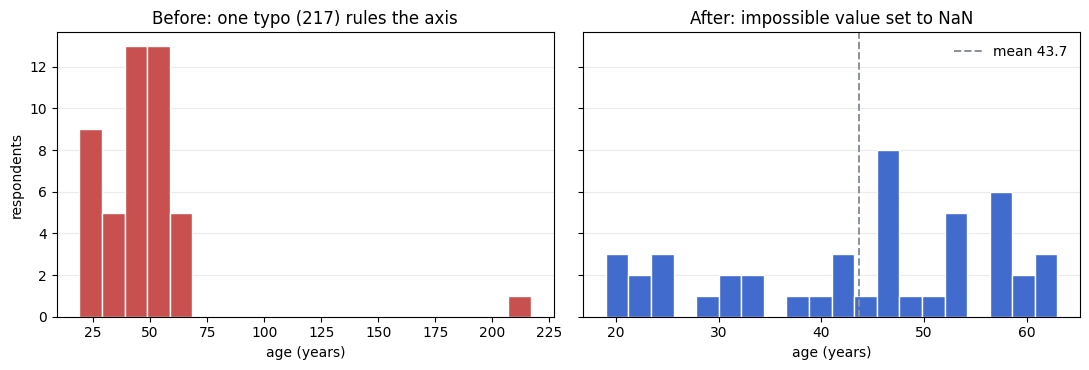

mean age  47.5  ->  43.7
std  age  28.7  ->  13.3


In [25]:
age_raw = raw["age"].dropna()
age_fixed = raw["age"].where(raw["age"] <= 110).dropna()   # the impossible value -> NaN -> dropped

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)

axes[0].hist(age_raw, bins=20, color=BAS_RED, edgecolor="white")
axes[0].set_title("Before: one typo (217) rules the axis")
axes[0].set_xlabel("age (years)")
axes[0].set_ylabel("respondents")

axes[1].hist(age_fixed, bins=20, color=BAS_BLUE, edgecolor="white")
axes[1].axvline(age_fixed.mean(), color=BAS_GREY, linestyle="--", linewidth=1.4,
                label=f"mean {age_fixed.mean():.1f}")
axes[1].set_title("After: impossible value set to NaN")
axes[1].set_xlabel("age (years)")
axes[1].legend(frameon=False)

for ax in axes:
    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

print(f"mean age  {age_raw.mean():.1f}  ->  {age_fixed.mean():.1f}")
print(f"std  age  {age_raw.std():.1f}  ->  {age_fixed.std():.1f}")

One bad cell in 48 rows shifted the mean age by almost 4 years and **more than doubled** the standard
deviation — and in the left panel it also compressed all 45 real respondents into the leftmost bins, hiding the
actual shape of the distribution. A histogram exposes both problems in a second, which is the golden rule
again: **look at your data**.

## 9. Preprocessing for modelling

Cleaning makes data *correct*. Preprocessing makes it *usable by an algorithm*. Two transformations cover most
of what Notebooks 11–12 will need.

### 9.1 Scaling — putting columns on a comparable ruler

`age` runs 19–68; `income_eur` runs ~1500–21500. Any method based on distances or on the size of coefficients
(k-nearest neighbours, SVMs, PCA, regularised regression, neural networks) will treat income as thousands of
times more important simply because its numbers are bigger.

The standard fix is the **z-score**: subtract the mean, divide by the standard deviation. Every column then has
mean 0 and std 1. `StandardScaler` does exactly this — no magic, as we can verify by hand.

In [26]:
from sklearn.preprocessing import StandardScaler

# Scalers cannot handle NaN, so impute first (median — see section 4)
model_input = pd.DataFrame({
    "age": raw["age"].where(raw["age"] <= 110),
    "income_eur": raw["income_eur"],
    "hours_online": hours_num,
})
model_input = model_input.fillna(model_input.median())

# Manual z-score
manual = (model_input - model_input.mean()) / model_input.std(ddof=0)

# The scikit-learn equivalent
scaler = StandardScaler()
scaled = pd.DataFrame(scaler.fit_transform(model_input),
                      columns=model_input.columns, index=model_input.index)

print("means after scaling:", scaled.mean().round(6).tolist())
print("stds  after scaling:", scaled.std(ddof=0).round(6).tolist())
print("max absolute difference manual vs StandardScaler:",
      float((manual - scaled).abs().to_numpy().max()))
print()
print(scaled.head(3).round(3))

means after scaling: [-0.0, 0.0, 0.0]
stds  after scaling: [1.0, 1.0, 1.0]
max absolute difference manual vs StandardScaler: 0.0

     age  income_eur  hours_online
0  1.347      -0.088        -1.098
1 -0.458       0.082        -0.534
2  1.503      -0.003         0.030


The two agree to numerical precision (note `ddof=0`: `StandardScaler` divides by *n*, pandas' `.std()` by
*n − 1* by default — a small but real difference on small samples).

Scaling does **not** remove outliers: the €21 500 income is still the largest value, now at a z-score of about
+6.7. If that bothers your model, `RobustScaler` (median and IQR) or a log transform are the usual answers —
not deletion.

> 🚨 **The rule you must not break.** Fit the scaler on the **training data only**, then apply the *same*
> fitted scaler to validation/test data:
>
> ```python
> scaler.fit(X_train)            # learn mean & std here...
> X_train_s = scaler.transform(X_train)
> X_test_s  = scaler.transform(X_test)   # ...and only APPLY them here
> ```
>
> Calling `fit_transform` on the full dataset leaks information about the test set into training (its mean is
> baked into the transformation) and makes your accuracy optimistic. The same applies to imputation medians and
> to category lists. This is exactly why scikit-learn has **`Pipeline`** — see
> [Notebook 12 — The Scikit-Learn Workflow](12_scikit_learn_workflow.ipynb), where the whole
> impute → scale → encode → fit chain becomes a single leak-proof object.

### 9.2 Encoding categories — from text to numbers

Most algorithms only accept numbers. `pd.get_dummies` performs **one-hot encoding**: one new 0/1 column per
category.

In [27]:
encoded = pd.get_dummies(city, prefix="city", dtype=int)
print(encoded.head(6))
print()
print("column sums (= respondents per city):")
print(encoded.sum())

# drop_first=True removes one redundant column (k-1 columns describe k categories)
print()
print("with drop_first=True:", list(pd.get_dummies(city, prefix="city", drop_first=True).columns))

   city_Berlin  city_Hamburg  city_Munich
0            0             1            0
1            1             0            0
2            1             0            0
3            0             0            1
4            1             0            0
5            1             0            0

column sums (= respondents per city):
city_Berlin     17
city_Hamburg    17
city_Munich     14
dtype: int64

with drop_first=True: ['city_Hamburg', 'city_Munich']


Why *not* simply encode Berlin=0, Munich=1, Hamburg=2? Because that invents an order and a distance:
Hamburg would be "twice" Munich, and the model would take that arithmetic seriously. Label encoding is fine
for **ordinal** data (`"low" < "medium" < "high"`) and for tree-based models, but for nominal categories
one-hot is the safe default.

Watch the width: one-hot encoding a `city` column with 5 000 distinct values produces 5 000 columns. That is
where **collapsing rare categories** into `"other"` becomes tempting — an act with consequences we discuss in
the reflection below.

In [28]:
# Putting it together: a numeric matrix a model could actually consume
features = pd.concat([scaled, encoded], axis=1)
print("feature matrix:", features.shape)
print("dtypes:", features.dtypes.astype(str).unique().tolist())
features.head(3).round(3)

feature matrix: (48, 6)
dtypes: ['float64', 'int64']


,age,income_eur,hours_online,city_Berlin,city_Hamburg,city_Munich
0,1.347,-0.088,-1.098,0,1,0
1,-0.458,0.082,-0.534,1,0,0
2,1.503,-0.003,0.030,1,0,0


## 10. Wrapping it up — a reusable `clean_dataset()`

Cleaning that lives in twenty scattered cells is unreproducible: nobody (including you, next month) knows what
was applied in which order. Put it in a **function** — Notebook 5's lesson, now with a real payoff — and have it
**return a log** of what it did.

Note the *order of operations*, which matters:

1. normalise text and categories,
2. **parse dtypes** (so numbers are numbers and IDs are comparable),
3. handle impossible values,
4. deduplicate,
5. impute what remains,
6. report.

In [29]:
def clean_dataset(df: pd.DataFrame, max_age: float = 110.0) -> tuple[pd.DataFrame, list[str]]:
    """Clean the community-survey table and return (clean_df, log).

    Steps, in this deliberate order: tidy categories -> parse dtypes ->
    fix impossible values -> deduplicate -> impute -> report.

    Every decision here is a judgement call; the returned log is the audit trail.
    """
    out = df.copy()            # never mutate the caller's DataFrame
    log = []

    # 1) categories: whitespace, capitalisation, then known synonyms
    n_before = out["city"].nunique()
    out["city"] = out["city"].str.strip().str.title().replace(CITY_SYNONYMS)
    log.append(f"city: {n_before} labels -> {out['city'].nunique()} after strip/title/synonyms")

    # 2) dtypes: text numbers and text dates
    out["hours_online"] = pd.to_numeric(
        out["hours_online"].str.strip().str.replace(",", ".", regex=False), errors="coerce")
    out["signup_date"] = pd.to_datetime(out["signup_date"], format="%Y-%m-%d", errors="coerce")
    log.append(f"hours_online -> numeric ({int(out['hours_online'].isna().sum())} unparseable -> NaN)")
    log.append(f"signup_date  -> datetime ({int(out['signup_date'].isna().sum())} unparseable -> NaT)")

    # 3) impossible values become missing (they are errors, not extremes)
    n_bad = int((out["age"] > max_age).sum())
    out.loc[out["age"] > max_age, "age"] = np.nan
    log.append(f"age: {n_bad} impossible value(s) > {max_age:.0f} set to NaN")

    # 4) duplicates: exact rows, then repeated respondent IDs (keep the latest)
    n_rows = len(out)
    out = out.drop_duplicates()
    out = out.drop_duplicates(subset=["respondent_id"], keep="last").reset_index(drop=True)
    log.append(f"duplicates: {n_rows} rows -> {len(out)} rows")

    # 5) imputation: median, plus a flag so the absence stays visible
    for col in ["age", "income_eur", "hours_online", "satisfaction"]:
        n_missing = int(out[col].isna().sum())
        if n_missing:
            median = out[col].median()               # computed BEFORE filling
            out[col + "_missing"] = out[col].isna()
            out[col] = out[col].fillna(median)
            log.append(f"{col}: {n_missing} NaN filled with median {median:.1f} (+ flag column)")

    return out, log


clean, cleaning_log = clean_dataset(raw)

print("--- cleaning log ---")
for line in cleaning_log:
    print(" •", line)
print()
_ = audit(clean, "cleaned survey")

--- cleaning log ---
 • city: 11 labels -> 3 after strip/title/synonyms
 • hours_online -> numeric (2 unparseable -> NaN)
 • signup_date  -> datetime (1 unparseable -> NaT)
 • age: 1 impossible value(s) > 110 set to NaN
 • duplicates: 48 rows -> 46 rows
 • age: 3 NaN filled with median 46.0 (+ flag column)
 • income_eur: 6 NaN filled with median 2910.0 (+ flag column)
 • hours_online: 2 NaN filled with median 2.5 (+ flag column)
 • satisfaction: 2 NaN filled with median 3.0 (+ flag column)

=== audit: cleaned survey ===
rows x columns   : 46 x 11
exact duplicates : 0
                               dtype  n_missing  pct_missing  n_unique
respondent_id                  int64          0          0.0        46
signup_date           datetime64[ns]          1          2.2        41
city                          object          0          0.0         3
age                          float64          0          0.0        29
income_eur                   float64          0          0.0        40


In [30]:
# Sanity checks: did we actually achieve what we claimed?
assert clean["city"].nunique() == 3, "city labels not normalised"
assert clean["hours_online"].dtype.kind == "f", "hours_online is not numeric"
assert pd.api.types.is_datetime64_any_dtype(clean["signup_date"]), "signup_date is not a datetime"
assert clean["respondent_id"].is_unique, "duplicate respondent IDs remain"
assert clean["age"].max() <= 110, "impossible age survived"
assert clean[["age", "income_eur", "hours_online", "satisfaction"]].isna().sum().sum() == 0

print("✅ all cleaning checks passed")
print(f"raw: {raw.shape}  ->  clean: {clean.shape}  (extra columns are the *_missing flags)")
clean.head()

✅ all cleaning checks passed
raw: (48, 7)  ->  clean: (46, 11)  (extra columns are the *_missing flags)


,respondent_id,signup_date,city,age,income_eur,hours_online,satisfaction,age_missing,income_eur_missing,hours_online_missing,satisfaction_missing
0,1001,2024-02-23,Hamburg,61.0,3000.0,1.0,5.0,False,False,False,False
1,1002,2024-07-01,Berlin,38.0,3460.0,1.9,4.0,False,False,False,False
2,1003,2024-02-28,Berlin,63.0,3230.0,2.8,4.0,False,False,False,False
3,1004,2024-10-10,Munich,33.0,2910.0,2.5,3.0,False,True,True,False
4,1005,2024-08-13,Berlin,30.0,1910.0,3.1,3.0,False,False,False,True


> 📓 **Document your cleaning, always.** Cleaning changes results — two analysts with the same raw file and
> different cleaning rules will report different numbers, and both can be "right". A minimal record for any
> project:
>
> - which rows/columns were removed, and **how many**;
> - which values were imputed, with what, and why that estimator;
> - which categories were merged or collapsed;
> - which values were judged errors, and on what evidence.
>
> A returned log (as above), a markdown cell in the notebook, or a `data_cleaning.md` next to the data all work.
> "I cleaned it" is not a method section. And keep the raw file **untouched** — cleaning must always be
> re-runnable from the original.

### 💬 Reflection — cleaning is not neutral

Everything in this notebook looked like a technical choice. None of it was only technical.

Recall section 4: the respondents who left `income_eur` blank were **younger and less satisfied** than the
rest. `dropna(subset=["income_eur"])` is one line of code, no error, no warning — and it quietly removed a
group from the analysis. Any model trained on what is left has never seen them, so it will predict worst
exactly for the people whose data was hardest to collect. The same mechanism appears throughout real practice:

- **Dropping incomplete rows** removes people with unstable employment, no permanent address, or a good reason
  to distrust a form — disproportionately the vulnerable.
- **Collapsing rare categories into `"other"`** (section 9.2) is a sensible way to keep a feature matrix
  narrow. It also merges small minorities into a bucket the model cannot distinguish, so their specific needs
  disappear into an average.
- **Deleting outliers** to get a nicer distribution deletes the unusual case — the fraud, the rare disease, the
  person whose situation the system was supposed to catch.
- **Imputing the median** asserts that a person is average in a respect where you have no information, and
  puts that assertion into every later statistic with no visible uncertainty.

Three questions worth answering in writing, for any cleaning step:

1. **Who is in the rows I removed?** Compare the dropped rows with the kept rows (`.describe()` on both) instead
   of assuming they are alike.
2. **Would I be comfortable if the affected people read my method section?**
3. **Is there an alternative that preserves the information?** A `*_missing` flag, an explicit `"unknown"`
   category, a group-wise imputation, a robust model — each keeps the group visible.

There is no rule that makes these choices for you, which is exactly why they must be *documented and
justified* rather than buried in an untitled cell. Cleaning decisions are where a dataset stops being a
record of the world and starts being an argument about it.

## 🏋️ Exercises

Five exercises, on a **new** messy table so nothing is memorised from above. Run the cell below to create it,
then work through the tasks. Every solution is collapsed — write your own attempt first; the point is the
decision, not the syntax.

In [31]:
def make_messy_orders(seed: int = 7) -> pd.DataFrame:
    """A second messy table: online orders. Defects are hand-placed, as before."""
    rng = np.random.default_rng(seed)
    n = 34

    channel = rng.choice(["Web", "App", "Phone"], size=n, p=[0.5, 0.35, 0.15])
    price = np.round(rng.gamma(4.0, 22.0, size=n) + 8, 2)
    delivery = rng.integers(1, 8, size=n).astype(float)
    order_date = pd.Timestamp("2024-03-01") + pd.to_timedelta(rng.integers(0, 120, size=n), unit="D")

    df = pd.DataFrame({
        "order_id": np.arange(5001, 5001 + n),
        "order_date": order_date.strftime("%Y-%m-%d"),
        "channel": channel.astype(object),
        "price_eur": [f"{p:.2f} EUR" for p in price],     # numbers as text, with a unit
        "delivery_days": delivery,
        "customer_city": rng.choice(["Berlin", "Munich", "Hamburg"], size=n).astype(object),
    })

    # messy channel labels
    for pos, value in {1: "web", 4: " Web", 8: "WEB", 12: "app ",
                       17: "Mobile App", 23: "phone", 29: "Telephone"}.items():
        df.loc[pos, "channel"] = value

    # unparseable prices and a genuine large order
    df.loc[2, "price_eur"] = "unknown"
    df.loc[10, "price_eur"] = "89,50 EUR"      # decimal comma
    df.loc[19, "price_eur"] = ""
    df.loc[27, "price_eur"] = "1450.00 EUR"    # a real bulk order

    # missing delivery times, one impossible value
    df.loc[[5, 13, 22, 31], "delivery_days"] = np.nan
    df.loc[16, "delivery_days"] = -3.0         # impossible

    # duplicates: one exact copy, one order_id re-submitted with a different channel
    resub = df.loc[[7]].copy()
    resub["channel"] = "Phone"
    resub["delivery_days"] = 6.0
    df = pd.concat([df, df.loc[[24]], resub], ignore_index=True)
    return df


orders = make_messy_orders()
orders.head()

,order_id,order_date,channel,price_eur,delivery_days,customer_city
0,5001,2024-06-10,App,59.17 EUR,6.0,Berlin
1,5002,2024-06-06,web,59.21 EUR,3.0,Hamburg
2,5003,2024-06-25,App,unknown,1.0,Berlin
3,5004,2024-03-02,Web,84.05 EUR,4.0,Munich
4,5005,2024-06-12,Web,91.38 EUR,4.0,Hamburg


### Exercise 8.1 — Audit a new table

Run a full audit of `orders` and answer, in a comment or a `print`:

1. How many rows and columns are there?
2. Which columns have the wrong dtype, and what should they be?
3. Which columns contain missing values according to `isna()` — and which column has **hidden** missing values
   that `isna()` cannot see?
4. How many exact duplicate rows are there, and how many `order_id`s occur more than once?

In [32]:
# Your code here  👇

<details>
<summary>💡 Click to reveal the solution</summary>

```python
report = audit(orders, "orders")

print("\n1) shape:", orders.shape)
print("2) wrong dtypes: order_date (object -> datetime), price_eur (object -> float);")
print("   channel/customer_city are legitimately object/text")
print("3) isna() finds gaps only in delivery_days;")
print("   price_eur hides '', 'unknown' and '89,50 EUR' as *strings*")
print("4) exact duplicates:", orders.duplicated().sum(),
      "| repeated order_ids:", int(orders.duplicated(subset=["order_id"]).sum()))
print("   rows involved in an order_id duplication:",
      int(orders.duplicated(subset=["order_id"], keep=False).sum()))
```

**Reasoning.** The audit shows 36 rows × 6 columns. `isna()` reports missing values only for
`delivery_days` (4) — but `price_eur` is an `object` column, so `""` and `"unknown"` are *strings* and count as
present. `nunique()` on `order_id` (34 for 36 rows) plus `duplicated(subset=["order_id"])` reveals the two
duplicated identifiers: one exact copy and one re-submission. This is why the dtype step must come before the
missing-value step — until `price_eur` is numeric you cannot even count its gaps.
</details>

### Exercise 8.2 — Repair the dtypes

Turn `price_eur` into a real `float` column called `price` and `order_date` into a `datetime64` column.

- Strip the `" EUR"` suffix and handle the German decimal comma (`"89,50 EUR"` must become `89.5`, **not** `NaN`).
- Use `errors="coerce"` and **print which original strings were destroyed** by the coercion.
- Then compute the mean and median order value, and the number of days between the first and last order.

In [33]:
# Your code here  👇

<details>
<summary>💡 Click to reveal the solution</summary>

```python
price_text = orders["price_eur"].str.replace("EUR", "", regex=False).str.strip()
price = pd.to_numeric(price_text.str.replace(",", ".", regex=False), errors="coerce")

print("strings that became NaN:", orders.loc[price.isna(), "price_eur"].tolist())

orders_fixed = orders.copy()
orders_fixed["price"] = price
orders_fixed["order_date"] = pd.to_datetime(orders["order_date"], format="%Y-%m-%d", errors="coerce")

print("\ndtypes:", orders_fixed["price"].dtype, orders_fixed["order_date"].dtype)
print(f"mean price   : {price.mean():.2f} EUR")
print(f"median price : {price.median():.2f} EUR")
span = orders_fixed["order_date"].max() - orders_fixed["order_date"].min()
print("order window :", span.days, "days")
```

**Reasoning.** Replacing the decimal comma *before* coercion rescues `"89,50 EUR"`; without it that order
would silently vanish. Only `""` and `"unknown"` become `NaN` — genuinely unknown prices, now *visible* to
`isna()`. Notice that mean > median: the €1450 bulk order pulls the mean up, which is the usual reason to
prefer the median for money.
</details>

### Exercise 8.3 — Categories and duplicates

1. Tidy `channel` so that only three labels remain: `Web`, `App`, `Phone`. Show `value_counts()` before and
   after. (`"Mobile App"` and `"Telephone"` need an explicit mapping.)
2. Remove exact duplicate rows, then keep only the **last** record per `order_id`.
3. Report how many rows you removed in total — and write one sentence on why deduplicating on the whole row
   would be the wrong call for a table of orders.

In [34]:
# Your code here  👇

<details>
<summary>💡 Click to reveal the solution</summary>

```python
print("BEFORE:")
print(orders["channel"].value_counts())

CHANNEL_SYNONYMS = {"Mobile App": "App", "Telephone": "Phone"}
channel = orders["channel"].str.strip().str.title().replace(CHANNEL_SYNONYMS)

print("\nAFTER:")
print(channel.value_counts())

tidy = orders.assign(channel=channel)
n0 = len(tidy)
tidy = tidy.drop_duplicates()
tidy = tidy.drop_duplicates(subset=["order_id"], keep="last").reset_index(drop=True)
print(f"\nrows removed: {n0 - len(tidy)}  ({n0} -> {len(tidy)})")
print("order_id unique:", tidy["order_id"].is_unique)
```

`.str.strip().str.title()` collapses `" Web"`, `"web"` and `"WEB"` onto `"Web"`; the two synonyms need domain
knowledge, so they live in a named dictionary. Deduplicating on the whole row would be wrong for orders because
**two different customers can legitimately place identical orders** (same day, same price, same channel);
`order_id` is the real identifier, so dedupe on that and keep the latest correction.
</details>

### Exercise 8.4 — Debug me 🐞

The cell below is supposed to (a) fill the missing `delivery_days` with the median and (b) remove duplicate
rows. Run it. **It raises no error — and it also does nothing.** Find out why, then write a corrected version.

Hint: look very closely at what each line does with its *result*.

In [35]:
# 🐞 Buggy — this runs happily and changes nothing. Why?
buggy = orders.copy()

buggy["delivery_days"].fillna(buggy["delivery_days"].median())
buggy.drop_duplicates()

print("missing delivery_days:", int(buggy["delivery_days"].isna().sum()), "(expected 0)")
print("duplicate rows       :", int(buggy.duplicated().sum()), "(expected 0)")

missing delivery_days: 4 (expected 0)
duplicate rows       : 1 (expected 0)


<details>
<summary>💡 Click to reveal the solution</summary>

Both pandas methods are **not** in-place: they *return a new object* and leave the original untouched. The
buggy lines compute the correct answer and then throw it away, because nothing is assigned. No error, no
warning — the most dangerous kind of bug.

```python
fixed = orders.copy()

# (a) assign the result back
fixed["delivery_days"] = fixed["delivery_days"].fillna(fixed["delivery_days"].median())

# (b) rebind the DataFrame
fixed = fixed.drop_duplicates()

print("missing delivery_days:", int(fixed["delivery_days"].isna().sum()))
print("duplicate rows       :", int(fixed.duplicated().sum()))
print("shape:", orders.shape, "->", fixed.shape)
```

**Two related traps to remember.**

1. `inplace=True` looks like the fix, but it is discouraged in modern pandas (it does not always avoid a copy,
   it breaks method chaining, and on a slice it can fail silently). Assign the result instead.
2. *Chained* assignment such as `fixed[fixed["x"].isna()]["x"] = 0` has the same failure mode: the first `[]`
   may return a copy, so the write lands on a temporary object and disappears. Use one indexer:
   `fixed.loc[fixed["x"].isna(), "x"] = 0`.

Moral: after any cleaning step, *verify* it — `assert fixed["delivery_days"].isna().sum() == 0` would have
caught this instantly.
</details>

### Exercise 8.5 — Compose a `clean_orders()` function

Write `clean_orders(df)` that returns `(clean_df, log)` and performs, in a sensible order:

1. tidy `channel` (three labels);
2. parse `price` (float) and `order_date` (datetime);
3. turn the impossible `delivery_days = -3` into `NaN`;
4. deduplicate on `order_id`, keeping the last record;
5. impute the remaining numeric gaps with the median **and** add `*_missing` flag columns;
6. return a log of what happened.

Then build a small model-ready matrix: z-score `price` and `delivery_days`, one-hot encode `channel`, and print
the resulting shape. Finish with one sentence on why the scaling you just did would be **wrong** inside a real
train/test workflow.

In [36]:
# Your code here  👇

<details>
<summary>💡 Click to reveal the solution</summary>

```python
def clean_orders(df):
    """Clean the orders table; return (clean_df, log)."""
    out = df.copy()
    log = []

    # 1) categories
    out["channel"] = out["channel"].str.strip().str.title().replace(
        {"Mobile App": "App", "Telephone": "Phone"})
    log.append(f"channel: {df['channel'].nunique()} -> {out['channel'].nunique()} labels")

    # 2) dtypes
    text = out["price_eur"].str.replace("EUR", "", regex=False).str.strip()
    out["price"] = pd.to_numeric(text.str.replace(",", ".", regex=False), errors="coerce")
    out = out.drop(columns="price_eur")
    out["order_date"] = pd.to_datetime(out["order_date"], format="%Y-%m-%d", errors="coerce")
    log.append(f"price -> float ({int(out['price'].isna().sum())} unparseable), order_date -> datetime")

    # 3) impossible values
    n_bad = int((out["delivery_days"] < 0).sum())
    out.loc[out["delivery_days"] < 0, "delivery_days"] = np.nan
    log.append(f"delivery_days: {n_bad} negative value(s) -> NaN")

    # 4) duplicates
    n0 = len(out)
    out = out.drop_duplicates().drop_duplicates(subset=["order_id"], keep="last").reset_index(drop=True)
    log.append(f"duplicates: {n0} -> {len(out)} rows")

    # 5) imputation + visibility flags
    for col in ["price", "delivery_days"]:
        n_missing = int(out[col].isna().sum())
        if n_missing:
            out[col + "_missing"] = out[col].isna()
            out[col] = out[col].fillna(out[col].median())
            log.append(f"{col}: {n_missing} NaN -> median {out[col].median():.2f} (+ flag)")

    return out, log


clean_orders_df, orders_log = clean_orders(orders)
for line in orders_log:
    print(" •", line)

# model-ready matrix
num = clean_orders_df[["price", "delivery_days"]]
z = (num - num.mean()) / num.std(ddof=0)
X = pd.concat([z, pd.get_dummies(clean_orders_df["channel"], prefix="ch", dtype=int)], axis=1)

print("\nfeature matrix:", X.shape)
print(X.head(3).round(3))
assert clean_orders_df["order_id"].is_unique
assert X.isna().sum().sum() == 0
print("\n✅ checks passed")
```

**Why this scaling would be wrong in a real workflow.** The mean and standard deviation (and the imputation
median) were computed from **all** rows, including the ones that would end up in the test set — so information
about the test data leaks into the transformation and the reported score is optimistic. In a real project you
fit those statistics on the training split only, inside a `Pipeline`; see
[Notebook 12](12_scikit_learn_workflow.ipynb).
</details>

## 🧠 Key takeaways

1. **Look at your data before you model it.** `.info()`, `.describe()`, `.isna().sum()`,
   `.duplicated().sum()`, `.nunique()` — five commands, one minute, most bugs caught.
2. **`isna()` only sees what pandas recognises as missing.** `"n/a"`, `""`, `-999` hide until you fix the dtype,
   so **repair dtypes early**: `pd.to_numeric(..., errors="coerce")`, `pd.to_datetime(..., format=...)` — and
   always print what the coercion destroyed.
3. **Missing values need a *why* before a *how*.** Missing at random is a nuisance; missing for a reason is
   information. Compare the rows with gaps against the rows without before deciding.
4. **Every missing-value strategy has a cost.** Dropping shrinks (and biases) the sample; mean/median filling
   shrinks the variance; `0` invents a claim. A `*_missing` flag keeps the absence visible.
5. **`.ffill()` / `.interpolate()` only make sense for ordered data**, and never use the deprecated
   `fillna(method=...)`.
6. **Deduplicate on an identifier, not reflexively on whole rows** — identical rows can be genuinely different
   observations, and parsing dtypes first prevents both false and missed matches.
7. **Categories must be normalised** (`.str.strip().str.title()`) *and* mapped (a named synonym dictionary);
   check `value_counts()` before and after.
8. **An outlier is either an error or the most important row in the table.** Impossible values → `NaN`; real
   extremes → keep. Decide with domain logic, not with a threshold.
9. **Preprocessing ≠ cleaning.** Scale so columns share a ruler, one-hot encode nominal categories — and fit
   every scaler/imputer on **training data only**.
10. **Wrap it in a function and log every decision.** Cleaning changes results, so it is part of your method,
    not a chore that precedes it. Keep the raw data untouched.

## ✅ Self-assessment

- [ ] I can audit an unknown table with five commands and interpret each output.
- [ ] I can explain the difference between *missing at random* and *missing for a reason*, and check for a pattern.
- [ ] I can defend a choice between `dropna`, `fillna(median)`, a group-wise fill and `.ffill()`.
- [ ] I can show numerically how mean-imputation distorts a distribution.
- [ ] I can convert text columns to numbers and dates with `errors="coerce"` and report what was lost.
- [ ] I can find exact and subset duplicates, and say when deduplication would destroy real data.
- [ ] I can normalise inconsistent category labels and verify the result with `value_counts()`.
- [ ] I can flag outliers with an IQR rule and a z-score, and argue whether each one is an error or real.
- [ ] I can standardise numeric features and one-hot encode categorical ones, and explain why the scaler must
      be fitted on training data only.
- [ ] I can package the whole pipeline in a documented function that returns a cleaning log.
- [ ] I can name one way a cleaning decision could disadvantage a specific group of people.

## 🚀 Next step

Your data is now trustworthy — time to *see* it. Continue with
**[Notebook 9 — Visualisation with Matplotlib](09_visualization_matplotlib.ipynb)**, where the quick diagnostic
histogram from section 8 grows into deliberate, communicative charts. After that,
[Notebook 10 — Exploratory Data Analysis](10_exploratory_data_analysis.ipynb) combines cleaning and plotting
into a real investigation.

⬅️ Previous: **[Notebook 7 — Pandas Essentials](07_pandas_essentials.ipynb)**